In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Smartphone_Usage.csv')
df.head()

,User_ID,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
0,U1,58,Male,Professional,Android,1.3,6.7,6,8.8,4,42,1,8.7
1,U2,25,Male,Professional,Android,1.2,1.5,5,6.4,1,51,3,5.1
2,U3,19,Male,Student,iOS,5.3,5.7,5,9.0,4,14,5,6.3
3,U4,35,Female,Business Owner,iOS,5.8,2.5,2,5.7,3,36,6,12.8
4,U5,33,Male,Freelancer,Android,7.9,1.3,4,5.7,3,37,5,9.9


In [3]:
df.shape

(50000, 13)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   User_ID                    50000 non-null  object 
 1   Age                        50000 non-null  int64  
 2   Gender                     50000 non-null  object 
 3   Occupation                 50000 non-null  object 
 4   Device_Type                50000 non-null  object 
 5   Daily_Phone_Hours          50000 non-null  float64
 6   Social_Media_Hours         50000 non-null  float64
 7   Work_Productivity_Score    50000 non-null  int64  
 8   Sleep_Hours                50000 non-null  float64
 9   Stress_Level               50000 non-null  int64  
 10  App_Usage_Count            50000 non-null  int64  
 11  Caffeine_Intake_Cups       50000 non-null  int64  
 12  Weekend_Screen_Time_Hours  50000 non-null  float64
dtypes: float64(4), int64(5), object(4)
memory usag

In [5]:
df.isnull().sum()

,0
User_ID,0
Age,0
Gender,0
Occupation,0
Device_Type,0
Daily_Phone_Hours,0
Social_Media_Hours,0
Work_Productivity_Score,0
Sleep_Hours,0
Stress_Level,0


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
Q1 = df['Daily_Phone_Hours'].quantile(0.25)
Q3 = df['Daily_Phone_Hours'].quantile(0.75)
IQR = Q3 - Q1
LF= Q1- (1.5 * IQR)
UF= Q3+ (1.5 * IQR)

outliers = df[(df['Daily_Phone_Hours'] < LF) | (df['Daily_Phone_Hours'] > UF)]
outliers

,User_ID,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours


<Axes: xlabel='Daily_Phone_Hours', ylabel='Count'>

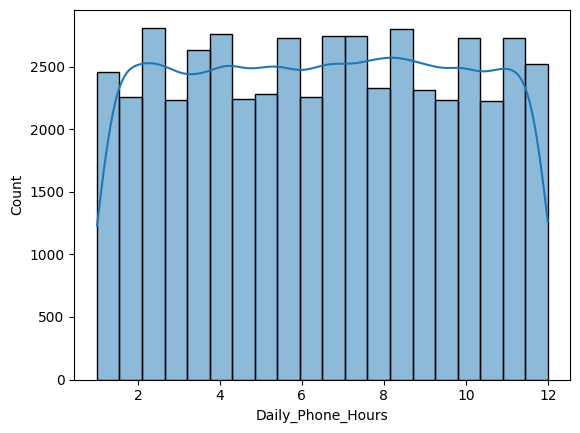

In [8]:
sns.histplot(df['Daily_Phone_Hours'], bins=20, kde=True)

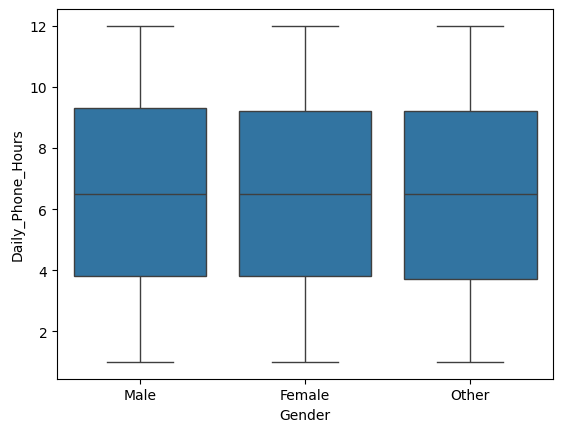

In [9]:
sns.boxplot(x='Gender' , y='Daily_Phone_Hours' , data=df)
plt.show()

In [10]:
df.groupby('Gender')['Daily_Phone_Hours'].mean()

,Daily_Phone_Hours
Gender,
Female,6.509989
Male,6.522696
Other,6.494583


In [11]:
df.columns

Index(['User_ID', 'Age', 'Gender', 'Occupation', 'Device_Type',
       'Daily_Phone_Hours', 'Social_Media_Hours', 'Work_Productivity_Score',
       'Sleep_Hours', 'Stress_Level', 'App_Usage_Count',
       'Caffeine_Intake_Cups', 'Weekend_Screen_Time_Hours'],
      dtype='object')

<Axes: xlabel='Age', ylabel='Daily_Phone_Hours'>

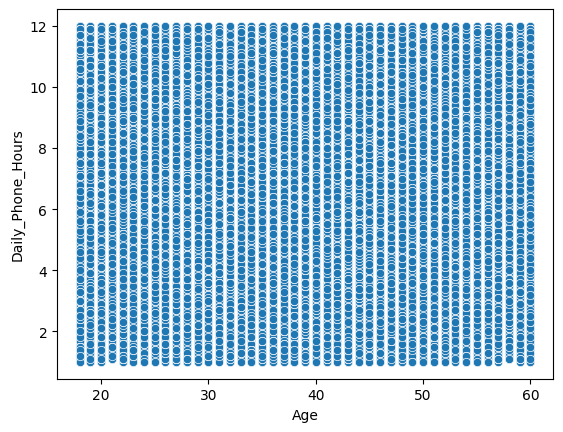

In [12]:
sns.scatterplot(x='Age',y='Daily_Phone_Hours',data=df)

In [13]:
df['Age_Group'] = pd.cut(df['Age'], bins=[10,20,30,40,50,60])
df.groupby('Age_Group')['Daily_Phone_Hours'].mean()

/tmp/ipython-input-207/2623647032.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Age_Group')['Daily_Phone_Hours'].mean()


,Daily_Phone_Hours
Age_Group,
"(10, 20]",6.467466
"(20, 30]",6.478753
"(30, 40]",6.495406
"(40, 50]",6.549737
"(50, 60]",6.524250


Exercise 1:
Find top 10% users by daily usage.

Exercise 2:
Plot average usage per age group.

Exercise 3:
Find which gender has highest average addiction level.

In [14]:
#Identify top 25% heavy users
target_percentile = df['Daily_Phone_Hours'].quantile(0.75)
df[df['Daily_Phone_Hours'] > target_percentile]

,User_ID,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours,Age_Group
5,U6,32,Female,Student,Android,10.9,4.2,9,6.3,7,34,5,3.6,"(30, 40]"
8,U9,52,Female,Business Owner,Android,9.4,2.5,3,6.4,4,17,3,3.1,"(50, 60]"
11,U12,45,Other,Business Owner,Android,12.0,6.7,6,4.9,10,12,1,9.2,"(40, 50]"
12,U13,20,Female,Business Owner,iOS,11.1,5.6,3,5.0,4,22,6,4.2,"(10, 20]"
13,U14,19,Female,Freelancer,iOS,9.7,4.1,10,6.0,1,36,6,2.3,"(10, 20]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49970,U49971,25,Male,Freelancer,Android,11.2,2.8,3,7.1,1,39,6,9.7,"(20, 30]"
49977,U49978,19,Male,Professional,Android,10.7,4.8,1,6.2,2,23,2,3.6,"(10, 20]"
49982,U49983,42,Female,Professional,iOS,9.3,6.8,3,7.8,9,13,4,7.5,"(40, 50]"
49991,U49992,42,Female,Business Owner,Android,11.1,1.4,6,8.2,7,33,5,8.6,"(40, 50]"


In [15]:
df.columns

Index(['User_ID', 'Age', 'Gender', 'Occupation', 'Device_Type',
       'Daily_Phone_Hours', 'Social_Media_Hours', 'Work_Productivity_Score',
       'Sleep_Hours', 'Stress_Level', 'App_Usage_Count',
       'Caffeine_Intake_Cups', 'Weekend_Screen_Time_Hours', 'Age_Group'],
      dtype='object')

In [16]:
df['usage_segment'] = pd.qcut(df['Daily_Phone_Hours'],
                              q=4,
                              labels=['Low','Moderate','High','Extreme'])

In [18]:
df[['usage_segment','Daily_Phone_Hours']]

,usage_segment,Daily_Phone_Hours
0,Low,1.3
1,Low,1.2
2,Moderate,5.3
3,Moderate,5.8
4,High,7.9
...,...,...
49995,Moderate,5.9
49996,Low,2.9
49997,Low,1.4
49998,High,8.9


In [19]:
df['test_usage'] = pd.qcut(df['Daily_Phone_Hours'],
                           q=[0,0.5,1.0],
                           labels=['a','b'])

In [20]:
df.test_usage

,test_usage
0,a
1,a
2,a
3,a
4,b
...,...
49995,a
49996,a
49997,a
49998,b


In [22]:
df['test_deciles'] = pd.qcut(df['Daily_Phone_Hours'],
                             q=10,
                             labels=['a','b','c','d','e','f','g','h','i','j'])

In [23]:
df.test_deciles

,test_deciles
0,a
1,a
2,d
3,e
4,g
...,...
49995,e
49996,b
49997,a
49998,h


In [27]:
df.groupby('usage_segment').mean(numeric_only=True)

/tmp/ipython-input-207/3930168622.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('usage_segment').mean(numeric_only=True)


,Age,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
usage_segment,,,,,,,,,
Low,38.931169,2.418664,4.289808,5.509071,6.502974,5.557580,32.361520,3.001324,8.042124
Moderate,39.001716,5.195382,4.231042,5.495055,6.490225,5.445116,32.404005,2.981610,7.953257
High,39.055231,7.900864,4.275842,5.518690,6.516129,5.505403,32.428400,2.993516,8.016849
Extreme,39.154558,10.630131,4.270947,5.491834,6.481262,5.507201,32.564084,3.041677,8.013082


<Axes: xlabel='usage_segment', ylabel='Sleep_Hours'>

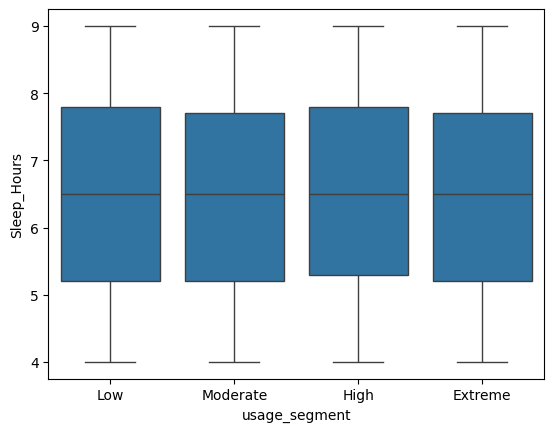

In [28]:
sns.boxplot(data=df, x='usage_segment',y='Sleep_Hours')

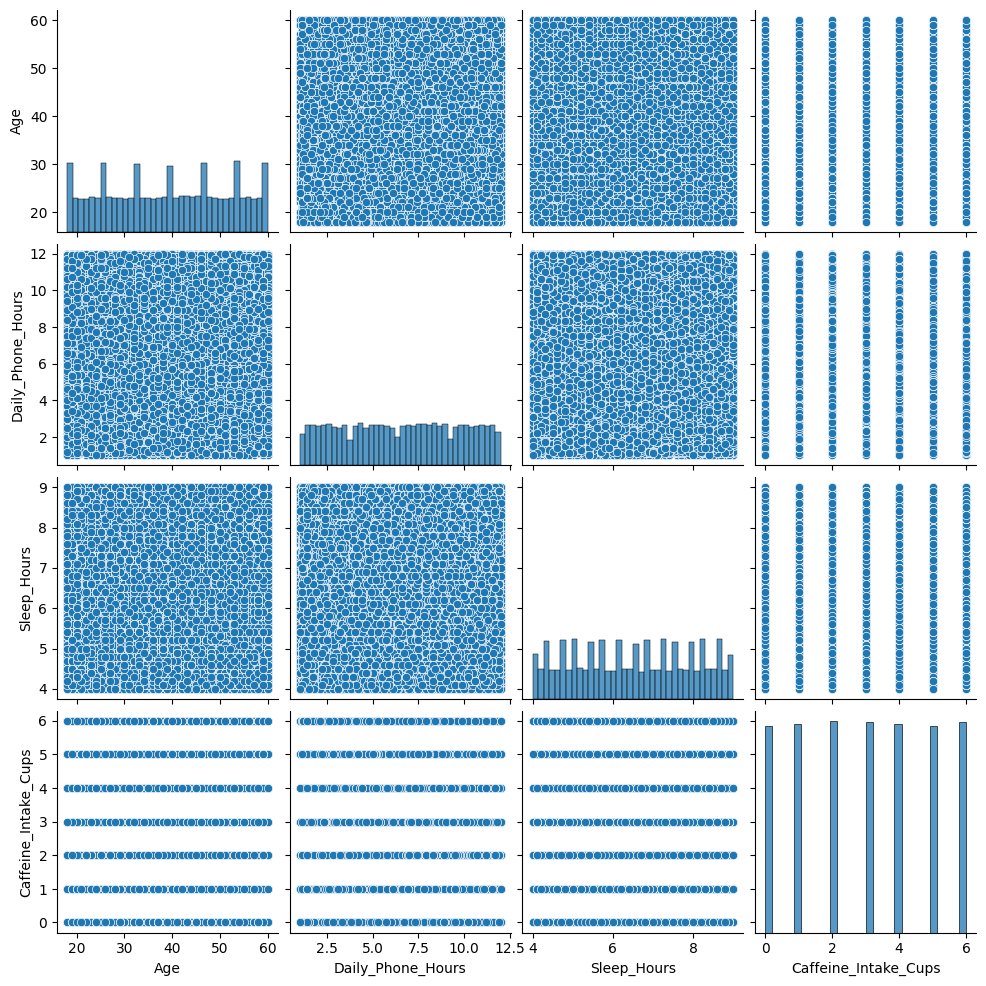

In [30]:
sns.pairplot(df[['Age','Daily_Phone_Hours','Sleep_Hours','Caffeine_Intake_Cups']])